# Module 5 Lab: Classification With the Titanic Dataset
**Name:** James Okooboh

## Part 0: Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Part 1: Load & Explore the Data

In [2]:
df = pd.read_csv('titanic.csv')
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

**Observation:** Cabin is missing for 687 of 891 passengers, so it can't be used as-is. Age is missing for 177 passengers (about 20%), which is too many to drop, so we'll fill those gaps instead. Embarked is missing for only 2 passengers and can be filled with the most common port.

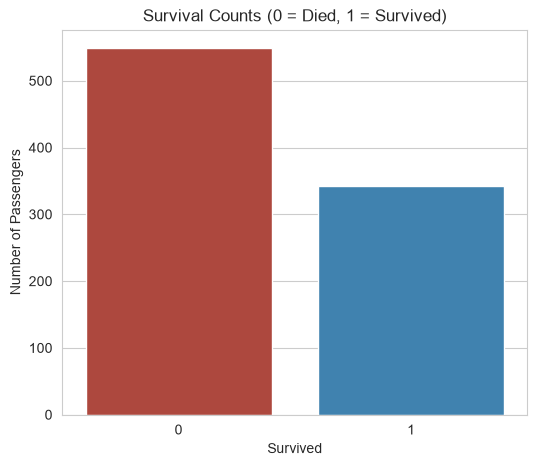

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=df, hue='Survived',
              palette=['#C0392B', '#2E86C1'], legend=False)
plt.title('Survival Counts (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

print(df['Survived'].value_counts(normalize=True).round(3))

**Observation:** About 62% of passengers died and 38% survived. The classes are somewhat imbalanced, so we shouldn't rely on accuracy alone. Precision, recall and F1 will give a fuller picture.

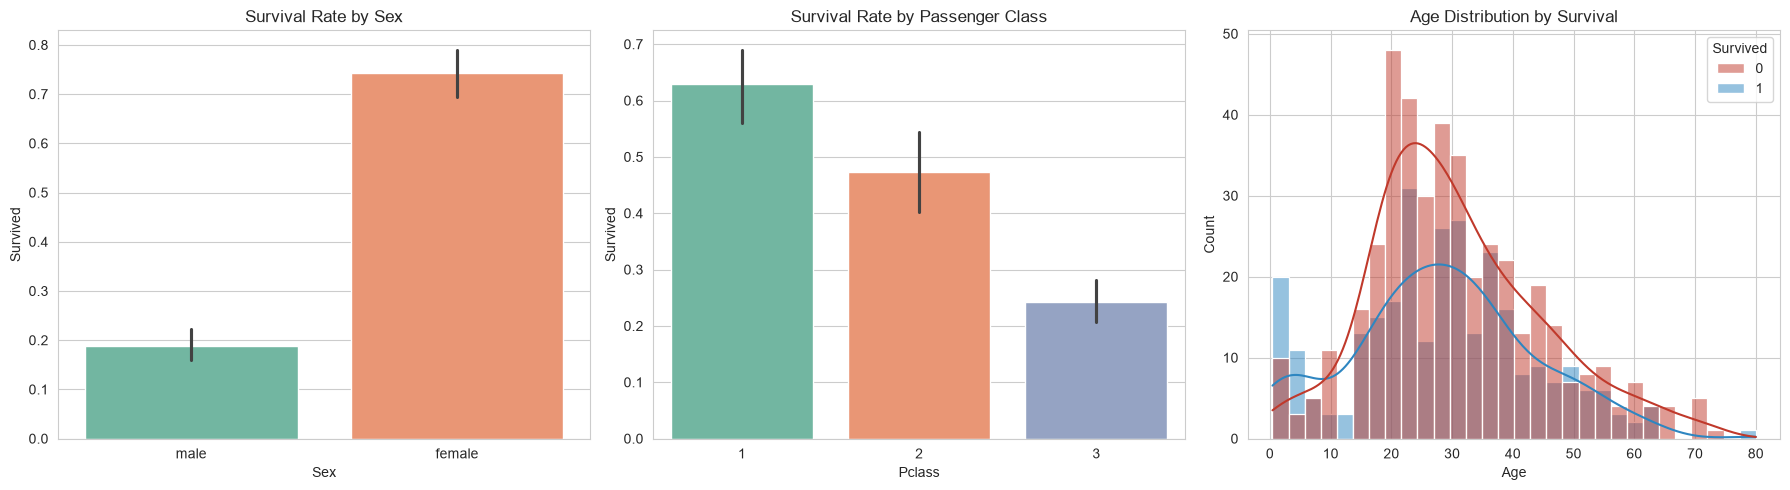

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Sex', y='Survived', data=df, hue='Sex',
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass',
            palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True,
             palette=['#C0392B', '#2E86C1'], ax=axes[2])
axes[2].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

**Observation:** Women survived at a far higher rate than men, reflecting the "women and children first" policy. First-class passengers also survived much more often than 2nd or 3rd class, likely due to better access to lifeboats. Age shows a weaker pattern, though young children survived slightly more often.

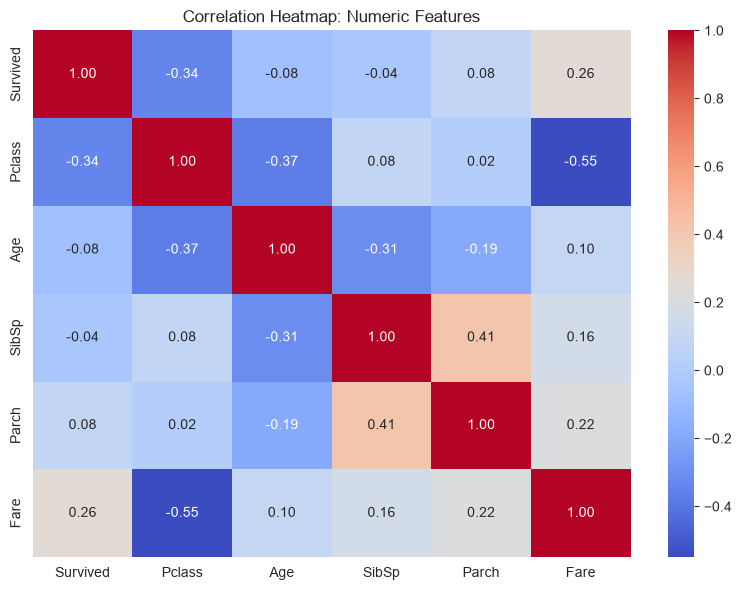

In [8]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Numeric Features')
plt.tight_layout()
plt.show()

**Observation:** Pclass has the strongest numeric correlation with survival (−0.34): higher class numbers, meaning cheaper tickets, go with lower survival. Fare is positively correlated (0.26), which tells the same story from the other direction. Age, SibSp and Parch have only weak correlations on their own. Sex isn't shown because it's still text, but Task 5 showed it is a very strong predictor.

## Part 2: Data Cleaning & Feature Engineering

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print('Remaining missing Age:', df['Age'].isnull().sum())
print('Remaining missing Embarked:', df['Embarked'].isnull().sum())

Remaining missing Age: 0
Remaining missing Embarked: 0


In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [11]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked',
 'FamilySize']

In [12]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


**Observation:** Sex is now 0/1 and Embarked has become two dummy columns (Embarked_Q, Embarked_S), with Cherbourg ('C') as the baseline when both are 0. FamilySize combines siblings/spouses and parents/children into one measure of group size. The dataset is now fully numeric and ready for modelling.

## Part 3: Train/Test Split & Feature Scaling

In [13]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (712, 9)  Test shape: (179, 9)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Note:** The scaler is fitted on the training data only, then applied to the test data. Fitting on the test set would leak information from it into training. Scaling matters most for KNN and SVM, which rely on distances between points.

## Part 4: Train Five Classification Models

In [15]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print('Logistic Regression trained.')

Logistic Regression trained.


In [16]:
dec_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
dec_tree.fit(X_train, y_train)
y_pred_tree = dec_tree.predict(X_test)
print('Decision Tree trained.')

Decision Tree trained.


In [17]:
rand_forest = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rand_forest.fit(X_train, y_train)
y_pred_rf = rand_forest.predict(X_test)
print('Random Forest trained.')

Random Forest trained.


In [18]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print('KNN trained.')

KNN trained.


In [19]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM trained.')

c:\Users\DELL\Documents\TECHYJAUNT_PROJECTS\Module2Assignment_venv\mlenv-venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained.


**Note:** Logistic Regression, KNN and SVM are trained on the scaled data because they are sensitive to feature scale. Decision Tree and Random Forest use the unscaled data, since tree-based models split on one feature at a time and aren't affected by scale.

## Part 5: Evaluate Every Model

In [20]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = [
    evaluate('Logistic Regression', y_test, y_pred_log),
    evaluate('Decision Tree', y_test, y_pred_tree),
    evaluate('Random Forest', y_test, y_pred_rf),
    evaluate('KNN', y_test, y_pred_knn),
    evaluate('SVM', y_test, y_pred_svm),
]

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.815642,0.790323,0.710145,0.748092
1,Logistic Regression,0.804469,0.793103,0.666667,0.724409
2,Random Forest,0.810056,0.857143,0.608696,0.711864
3,SVM,0.804469,0.826923,0.623188,0.710744
4,Decision Tree,0.759777,0.740741,0.579710,0.650407


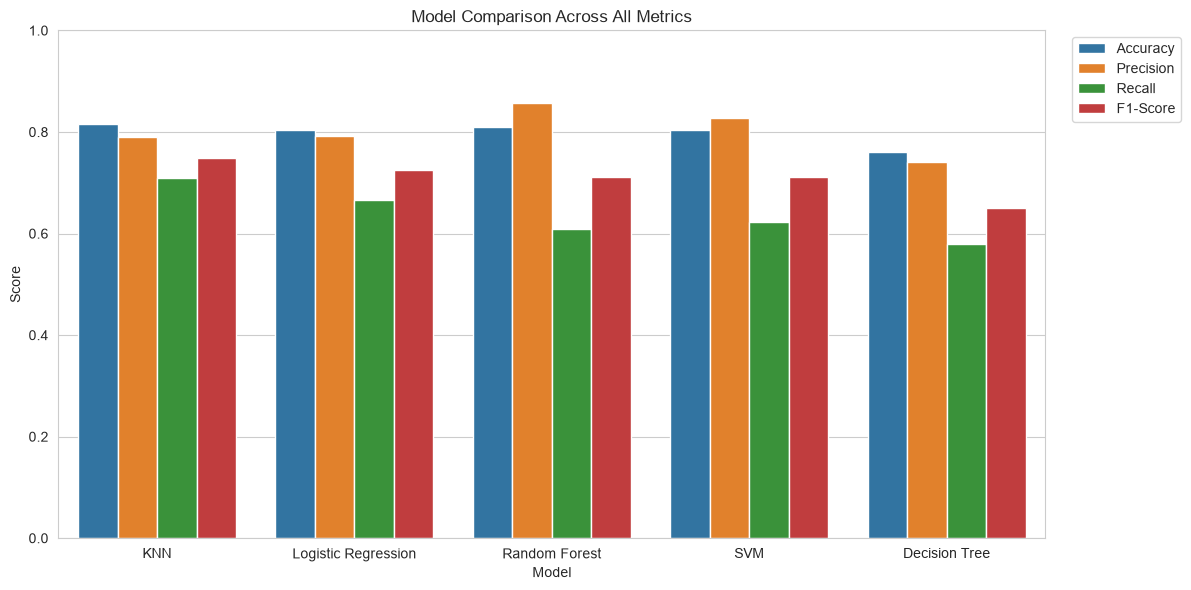

In [21]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across All Metrics')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** KNN performed best overall, with the highest accuracy (about 81.6%), recall (0.71) and F1-score (0.75). Random Forest had the highest precision (0.86): when it predicts someone survived, it's usually right, but its lower recall (0.61) means it misses more actual survivors. Logistic Regression and SVM landed close behind, while the Decision Tree was weakest on every metric. Across all models, recall is lower than precision, meaning the models find it harder to identify survivors than to identify passengers who died.

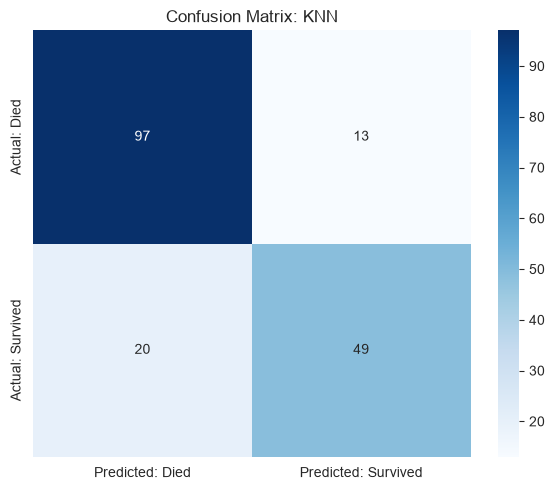

              precision    recall  f1-score   support

        Died       0.83      0.88      0.85       110
    Survived       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [22]:
best_model_name = results_df.iloc[0]['Model']
pred_map = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm
}
best_preds = pred_map[best_model_name]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_preds, target_names=['Died', 'Survived']))

**Observation:** KNN correctly predicted 97 passengers who died and 49 who survived. It made 13 false positives (predicted survived but died) and 20 false negatives (predicted died but actually survived). False negatives are the more common mistake here, which matches the lower recall for the Survived class (0.71). In a disaster-response setting, these missed survivors would be the more costly error.

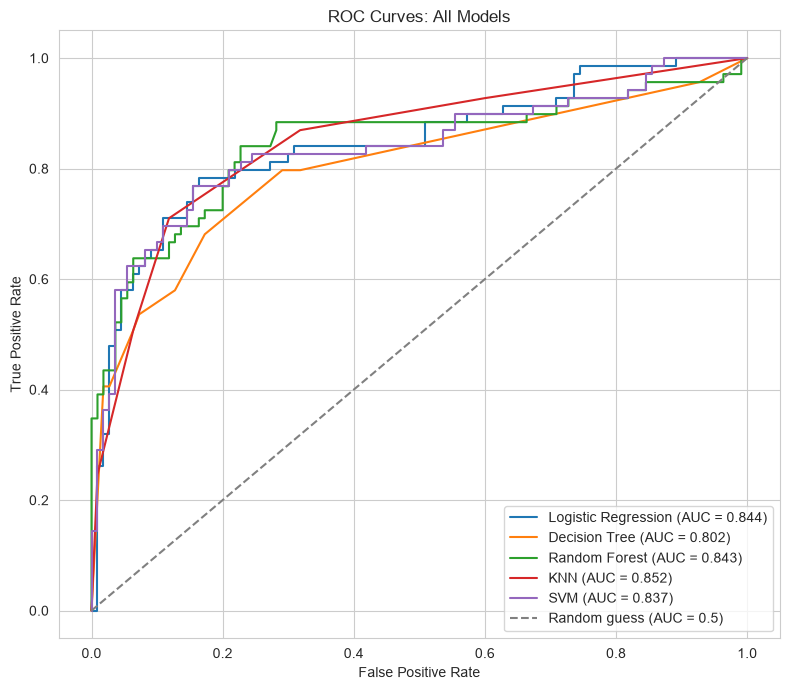

In [23]:
proba_map = {
    'Logistic Regression': log_reg.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': dec_tree.predict_proba(X_test)[:, 1],
    'Random Forest': rand_forest.predict_proba(X_test)[:, 1],
    'KNN': knn.predict_proba(X_test_scaled)[:, 1],
    'SVM': svm.predict_proba(X_test_scaled)[:, 1]
}

plt.figure(figsize=(8, 7))
for name, proba in proba_map.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Observation:** All five models perform well above random guessing (AUC = 0.5). KNN has the highest AUC (0.852), followed closely by Logistic Regression (0.844), Random Forest (0.843) and SVM (0.837), while the Decision Tree is lowest (0.802). Because AUC measures performance across every possible decision threshold, not just the default 0.5 cutoff, it confirms KNN as the strongest model overall. It also shows that Logistic Regression and Random Forest are almost as good at separating survivors from non-survivors, even though they had lower F1-scores at the default threshold.

## Part 6: Which Features Mattered Most?

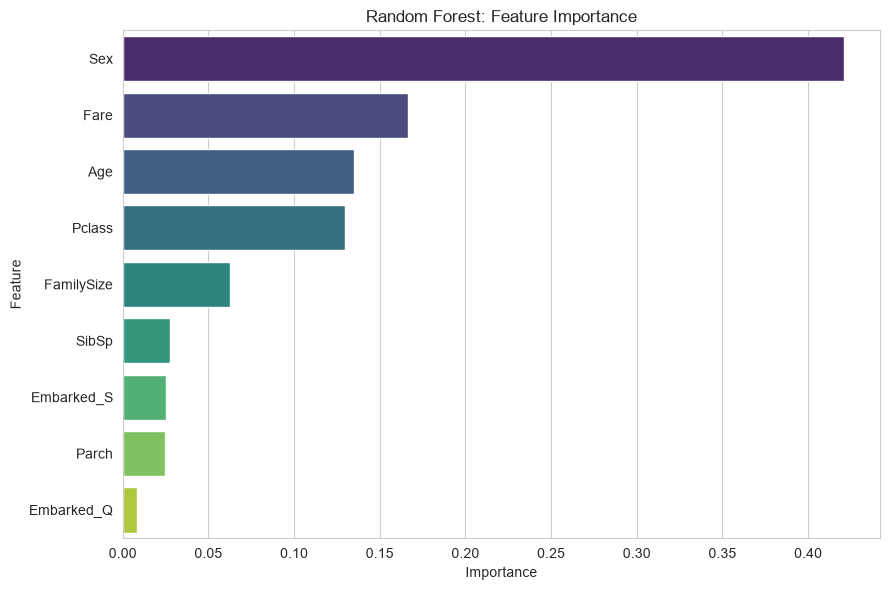

Sex           0.420874
Fare          0.166307
Age           0.134846
Pclass        0.129551
FamilySize    0.062885
SibSp         0.027588
Embarked_S    0.025121
Parch         0.024668
Embarked_Q    0.008161
dtype: float64

In [24]:
importances = pd.Series(rand_forest.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='viridis', legend=False)
plt.title('Random Forest: Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importances

**Observation:** Sex is by far the most important feature (about 0.42), followed by Fare (0.17), Age (0.13) and Pclass (0.13). This matches the exploration in Part 1, where sex and passenger class showed the clearest survival gaps. FamilySize, the feature we engineered, ranks fifth (0.06) and contributes more than SibSp or Parch individually, which shows that combining them into one feature was useful.

## Summary

In this lab I explored the Titanic dataset, cleaned it by filling missing Age and Embarked values and dropping unusable columns, encoded the categorical features, and engineered a FamilySize feature. I then split the data 80/20 with stratification, scaled the features for the distance-based models, and trained five classifiers: Logistic Regression, Decision Tree, Random Forest, KNN and SVM.

KNN performed best overall, with the highest accuracy (81.6%), F1-score (0.75) and ROC-AUC (0.852). The Decision Tree performed worst. Feature importance showed that Sex was by far the strongest predictor of survival, followed by Fare, Age and Pclass.

**Key takeaway:** no single metric tells the whole story. Random Forest had the highest precision but missed more survivors, while KNN balanced precision and recall best. That's why it matters to evaluate classifiers with precision, recall, F1 and ROC-AUC, not accuracy alone.